In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

from matplotlib.patches import Patch
from collections import Counter

def rSubset(arr, r):
    return list(combinations(arr, r))

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
contacts_unique_pro_bnd=pd.read_csv('../../../data/intra_protein_contacts/state_specific_contacts/UNIQ_CONTACTS_DATA_PRE_VS_BND.csv',
                                index_col=0)
contacts_unique_pro_bnd


,Ri,Ri region,Rj,Rj region,Unique to PRE or BND
0,4,M Nterm,9,M Nterm,PRE
1,4,M Nterm,39,M L3,PRE
2,5,M Nterm,9,M Nterm,PRE
3,8,M Nterm,12,M Nterm,PRE
4,10,M Nterm,36,M B1,PRE
5,17,R H2,105,R L7,PRE
6,23,HP1,51,HP1,PRE
7,23,HP1,108,HP1,PRE
8,24,R H2,103,R L7,PRE
9,24,R H2,107,R L7,PRE


In [3]:
cl_ri=[]

for i in contacts_unique_pro_bnd['Ri region']:
    if 'HP' in i:
        cl_ri.append('BPM')
    elif 'R ' in i:
        cl_ri.append('REST')
    elif 'M ' in i:
        cl_ri.append('MTM')

        
cl_rj=[]

for i in contacts_unique_pro_bnd['Rj region']:
    if 'HP' in i:
        cl_rj.append('BPM')
    elif 'R ' in i:
        cl_rj.append('REST')
    elif 'M ' in i:
        cl_rj.append('MTM')
        
        
contacts_unique_pro_bnd['Ri Cl']=cl_ri
contacts_unique_pro_bnd['Rj Cl']=cl_rj

contacts_unique_pro_bnd

,Ri,Ri region,Rj,Rj region,Unique to PRE or BND,Ri Cl,Rj Cl
0,4,M Nterm,9,M Nterm,PRE,MTM,MTM
1,4,M Nterm,39,M L3,PRE,MTM,MTM
2,5,M Nterm,9,M Nterm,PRE,MTM,MTM
3,8,M Nterm,12,M Nterm,PRE,MTM,MTM
4,10,M Nterm,36,M B1,PRE,MTM,MTM
5,17,R H2,105,R L7,PRE,REST,REST
6,23,HP1,51,HP1,PRE,BPM,BPM
7,23,HP1,108,HP1,PRE,BPM,BPM
8,24,R H2,103,R L7,PRE,REST,REST
9,24,R H2,107,R L7,PRE,REST,REST


In [4]:
def index_ret(segment, res_n):
    if segment=='MTM':
        return(MEM_RES.index(res_n))
    elif segment=='BPM':
        return(pock_res.index(res_n))
    elif segment=='REST':
        return(rest_res.index(res_n))
    
MEM_RES=[1,2,3,4,5,6,7,8,9,10,12,36,37,38,39,40,41,42,43,44,46,80,82,84,85,112,114,115,116,117,118,119]
pock_res=[19,23,32,34,51,53,108,35,52,54,55,58,63,66,67,70]
rest_res=[i for i in range(1,120) if i not in MEM_RES+pock_res]



membrane_binding_region=[('N-Terminal',0,10),('B1',11,12),('L3',13,20),
                        ('B3',21,22),('L6',23,24),
                         ('B4',25,26),('C-Terminal',27,32)]
rest_region=[('H2',1,12),('L2',13,15),('B1',16,18),('L3',19,23),
            ('L4',24,26),('H3',27,33),('L5',34,42),('L6',44,53),('H4',54,61),
            ('L7',62,66),('B4',67,70)]
pockets_L=[('HP1',0,7),('HP2',8,15)]

In [5]:
#1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 37, 38, 39, 40, 41, 42, 43, 45, 46, 119
LC3B_segments={'M Nterm':[1,2,3,4,5,6,7,8,9,10,12],
               'M B1':[36,37],
               'M L3':[38,39,40,41,42,43,44,46],
               'M B3':[80,82],
               'M L6':[84,85],
               'M B4': [112,114],
               'M Cterm': [115,116,117,118,119,120],
               
               'HP1':[19,23,32,34,51,53,108],
               'HP2':[35,52,54,55,58,63,66,67,70],
               
               'R ':[81,11], #OUTLYING NTERM B3 residues
               
               'R H2':[13,14,15,16,17,18,20,21,22,24,25,26],
               'R L2':[27,28,29],
               'R B1':[30,31,33],
               'R L3':[45,47,48,49,50],
               'R L4':[56,57,59],
               'R H3':[60,61,62,64,65,68,69],
               'R L5':[71,72,73,74,75,76,77,78,79],
               'R L6':[83,86,87,88,89,89,90,91,92,93,94],
               'R H4':[i for i in range(95,103)],
               'R L7':[i for i in range(103,108)],
               'R B4':[i for i in range(109,114)],
              'R Ext Cterm': [i for i in range (121,126)]}

cont_spec_data_ext_data=contacts_unique_pro_bnd


In [6]:
ss_seg_needed=['H2','H3','H4','L2','B1','B3','B4','L5','L6','L7','Cterm']
ss_seg_count_unb=[]
for seg in ss_seg_needed:
    counter=0
    for i,j,k,l,m in zip(cont_spec_data_ext_data['Ri region'],
                  cont_spec_data_ext_data['Rj region'],
                      cont_spec_data_ext_data['Ri'],
                      cont_spec_data_ext_data['Rj'],
                       cont_spec_data_ext_data['Unique to PRE or BND']):
        if m=='BND':
            if seg in i or seg in j:
                counter=counter+1
    ss_seg_count_unb.append(counter)

In [7]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }

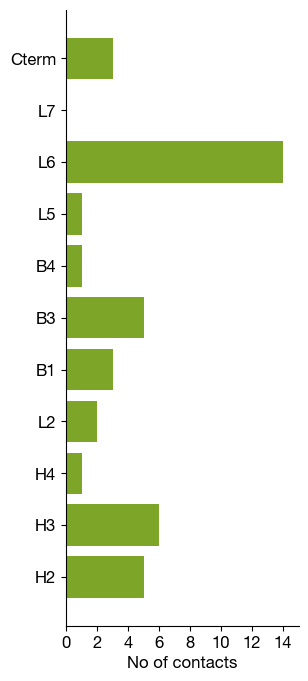

In [8]:
fig, ax = plt.subplots(figsize=(3,8))
ax.barh(ss_seg_needed, ss_seg_count_unb,color='#7DA629')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)
# ax.spines['left'].set_visible(False)

# ax.set_yticks([])
# ax.set_xticks([])
ax.set_xlim(0,15)

ax.set_yticks([i for i in range(len(ss_seg_needed))],
             ss_seg_needed,fontdict=font)

ax.set_xticks([0,2,4,6,8,10,12,14],[0,2,4,6,8,10,12,14]
              ,fontdict=font)

ax.set_xlabel('No of contacts',
             fontdict=font)

plt.savefig('../../../plots/intra_protein_contacts/state_specific_contacts/REST_associated_uniq_contacts_bnd_compared_with_pre.png',
           dpi=450, transparent=True)

In [9]:
for i,j,k,l,m in zip(cont_spec_data_ext_data['Ri region'],
                  cont_spec_data_ext_data['Rj region'],
                      cont_spec_data_ext_data['Ri'],
                      cont_spec_data_ext_data['Rj'],
                       cont_spec_data_ext_data['Unique to PRE or BND']):
    if m=="BND":
        if "L6" in i or "L6" in j:
            print(i,j,k,l,m)

R H3 R L6 60 92 BND
R H3 R L6 61 88 BND
R H3 R L6 61 89 BND
R H3 R L6 61 90 BND
R H3 R L6 64 88 BND
R H3 R L6 64 89 BND
R L5 R L6 79 89 BND
M B3 R L6 80 87 BND
M B3 R L6 80 89 BND
R  R L6 81 86 BND
R  R L6 81 89 BND
M B3 M L6 82 85 BND
R L6 R L6 87 91 BND
R L6 M Cterm 87 117 BND


In [10]:
#numbers extracted from ABOVE
bnd_cont_l6_asso_data=[('L6','H3',6),
                      ('L6', 'L5',1),
                     ('L6','B3',5),
                       ('L6','CT',1),
                      ('L6','L6',1)]

In [11]:
def hanging_line(point1, point2):
    import numpy as np

    a = (point2[1] - point1[1])/(np.cosh(point2[0]) - np.cosh(point1[0]))
    b = point1[1] - a*np.cosh(point1[0])
    x = np.linspace(point1[0], point2[0], 100)
    y = a*np.cosh(x) + b

    return (x,y)

def new_parabola_join(p_A,p_B,scaling_factor):
    if p_A<p_B:
        x_points=np.arange(p_A, p_B, 0.001)
    else:
        x_points=np.arange(p_B, p_A, 0.001)
    
    y_points=[]
    for i in x_points:
        y_points.append(((i-p_A)*(i-p_B))*scaling_factor)
    
    return x_points, y_points
def scaler(min_size, max_size, min_val, max_val, sizes):

    scaled_sizes = [(size - min_val) / (max_val - min_val) * (max_size - min_size) + min_size for size in sizes]

    return scaled_sizes



ss_set=['H3','B3','B4','H4','L5','CT','E-CT']
points_all=[(4, ss_set.index(i)) for i in ss_set]

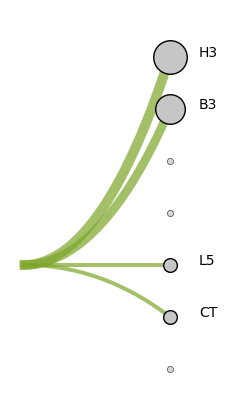

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3, 5))

line_scales=scaler(2,8, 0,7,[i[2] for i in bnd_cont_l6_asso_data])


counter=0
for p_dat in bnd_cont_l6_asso_data:
    counter=counter+1
    if p_dat[0]!=p_dat[1]:
        
        p_=(4, ss_set.index(p_dat[1]))
    
        point1 = [0,p_[0]+0]
        point2 = [1,p_[1]+0]
        x,y = hanging_line(point1, point2)


        ax.plot(x,y, lw=line_scales[counter-1], color='#7DA629',alpha=0.7)



        
marker_scales=scaler(7,27, 0,7,[i[2] for i in bnd_cont_l6_asso_data])
counter=0
for p_dat in bnd_cont_l6_asso_data:
    counter=counter+1
    if p_dat[0]!=p_dat[1]:   
        p_=(4, ss_set.index(p_dat[1]))
        
        point1 = [1,p_[1]]

        ax.plot(point1[0], point1[1], 'o', color='#C6C6C6',markersize=marker_scales[counter-1],
               markeredgecolor='black')
        ax.text(point1[0]+0.2,point1[1],"%s"%p_dat[1]) 
counter=0
for s_p in range(len(ss_set)):
    ax.scatter(1,s_p,s=20, facecolor='#C6C6C6',alpha=0.7,
              edgecolors='black',linewidths=0.5)
        
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(-0.1,1.5)
ax.set_ylim(-0.9,6.5)
ax.invert_yaxis()
plt.savefig('../../../plots/intra_protein_contacts/state_specific_contacts/L6_associated_contacts_bnd_compared_with_pre.png',
           dpi=450,bbox_inches='tight',
           transparent=True)